# 激光雷达直方图仿真 v3 (LiDAR Histogram Simulation)

从**激光器发光** → **TX 准直** → **传播/大气** → **目标漫反射(多回波)** → **RX 收集(焦距/口径/阵列)** → **SPAD 探测** → **TCSPC 直方图**。

**v3 相对 v2 的新增**
- **模块 8：Macro Pixel（宏像元）Binning**。把 `Bx×By` 个物理 SPAD 像元合并成一个"宏像元"，
  它对应一个很小的接收视场（iFOV_macro = B·pitch/f_RX）。**只有落在这个视场内的回波像斑光才被接收**，
  超出宏像元窗口的像斑光丢失。对比 **6×3 / 9×3 / 12×3** 三种宏像元尺寸对直方图的影响。

**v2 已有的修改**
1. 修复 RX（Receiver，接收端）像面光斑：几何成像 ⊕ 衍射艾里斑 平方和。
2. 脉冲宽度按 上升沿10% → 下降沿10% 全宽（10%-10%）报告。
3. 环境光噪声由 905nm 光谱辐照度 `E_lambda [W/m²/nm] × 12nm` 直接给定，泊松统计。
4. 每个回波(echo)单独放大特写子图。

**约定**：扩展面目标，功率 1/D²；椭圆高斯光斑；双指数脉冲；SPAD（Single-Photon Avalanche Diode，单光子雪崩二极管）
只考虑 PDE（Photon Detection Efficiency，光子探测效率），暂不考虑 dead time。

> ⚠️ 运行方式：**Kernel → Restart & Run All**（从上到下顺序执行；`link_factor` 等定义在模块 5，跳跑会 NameError）。

## 模块 0 — 参数与常数

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34   # 普朗克常数 [J·s]
D_PLOT_MAX = 300.0          # D 相关 plot 的统一距离范围 [m]

PARAMS = {
    # ---------- 激光源 ----------
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        "amp_mode": "peak",     # "peak"=用 P_peak 定幅 / "energy"=用 E_pulse 定幅
        "P_peak": 235.0,        # 峰值光功率 [W]
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J] (amp_mode="energy" 时生效)
        "tau_r": 0.7e-9,        # 双指数上升时间常数 [s]
        "tau_f": 1.9e-9,        # 双指数下降时间常数 [s]
        "x_L": 60e-6,           # 发光面 X 尺寸(慢轴, 1/e^2 全宽) [m]
        "y_L": 1150e-6,         # 发光面 Y 尺寸(快轴, 1/e^2 全宽) [m]
    },

    # ---------- TX 发射光学 ----------
    "tx": {
        "f_TX": 36e-3,          # 发射物镜焦距 [m]
        "D_TX": 12.7e-3,        # 发射通光口径 [m] -> w0 = D_TX/2
        "eta_coupling": 0.87,   # 发射角度耦合效率
        "T_TX": 0.92,           # 发射透过率
    },

    # ---------- 信道 / 大气 ----------
    "channel": {
        "alpha": 0.1e-3,        # 消光系数 @905nm [1/m]  (0.1/km≈晴朗)
        # 0.3e-3 小雨 / 0.6e-3 大雨 / 20e-3 大雾 / 60e-3 浓雾
    },

    # ---------- 目标 (多回波) ----------
    "target": {
        "echoes": [
            {"D": 30.0,  "rho": 0.10, "frac": 0.30, "tilt_deg": 0.0,  "name": "近处物体(边缘拦截)"},
            {"D": 120.0, "rho": 0.10, "frac": 0.60, "tilt_deg": 30.0, "name": "主目标(倾斜墙面)"},
            {"D": 200.0, "rho": 0.10, "frac": 0.10, "tilt_deg": 0.0,  "name": "远处背景"},
        ],
    },

    # ---------- RX 接收光学 ----------
    "rx": {
        "f_RX": 25e-3,          # 接收物镜焦距 [m]
        "D_RX": 13e-3,          # 接收口径 [m]
        "eta_RX": 0.82,         # 接收耦合效率
        "T_RX": 0.90,           # 接收透过率
        "T_filter": 0.90,       # 窄带滤光片透过率
        "filter_bw": 12e-9,     # 滤光片带宽 [m] (12 nm bandpass)
    },

    # ---------- SPAD 器件 ----------
    "spad": {
        "PDE": 0.30,            # 光子探测效率
        "DCR": 0.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 100e-12,# IRF 高斯 sigma [s]
    },

    # ---------- 方形 SPAD 阵列 ----------
    "spad_array": {
        "pitch": 10e-6,         # 方形像元间距 [m]
        "Nx": 100, "Ny": 1080,  # 阵列规模
        "fill_factor": 1.00,    # 填充因子(=1 表示不计死区/假设微透镜完全补偿)
        "sum_pixels": "illuminated",  # "illuminated"仅被照像元 / "all"整阵列
    },

    # ---------- Macro Pixel 宏像元 Binning (v3 新增) ----------
    # 把 Bx×By 个物理像元合并成一个宏像元, 对应视场 iFOV_macro = B·pitch/f_RX.
    # 只有落在宏像元窗口内的回波像斑光被接收(超出部分丢失).
    # 坐标约定(全局一致): x=短边(发光区60µm→像斑~7µm), y=长边(发光区1150µm→像斑~122µm).
    # 本例: 6/9/12 沿 x(短边), 3 沿 y(长边).
    #   → x窗口60/90/120µm 远超像斑7µm ⇒ x方向都≈全收; y窗口固定30µm 罩不住122µm长条.
    #   ⇒ 三种收集比例几乎相同(~0.48), 差异只在背景像元数(18/27/36). 这是真实配置的物理结果.
    "macro": {
        "sizes_xy": [(6, 3), (9, 3), (12, 3)],   # (Bx 沿短边x, By 沿长边y) 的宏像元尺寸列表
    },

    # ---------- 环境光 (直接给辐照值, 不做 lux 光谱假设) ----------
    "ambient": {
        "enable": True,         # 是否计入环境光
        # 905nm 处光谱辐照度 [W/m²/nm]. 100klux 白天太阳 AM1.5 附近典型 ~0.5-0.7; 按你的实测改.
        "E_lambda": 0.68,
        "surface_rho": 0.10,    # 被观测目标面反射率(用于环境光漫反射, 可与 echo 不同)
    },

    # ---------- 直方图 / TCSPC ----------
    "hist": {
        "t_max": 2048e-9,       # 时间窗 [s] (~307 m)
        "bin_width": 1e-9,      # bin 宽 [s]
        "dt_fine": 10e-12,      # 卷积精细网格 [s]
        "N_shots": 4,           # 累加脉冲数
        "seed": 0,
    },
}

E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]
print(f"单光子能量 E_photon = {E_PHOTON:.3e} J  ({E_PHOTON/1.602e-19:.3f} eV)")
print(f"1 ns bin -> 距离分辨 {C_LIGHT*1e-9/2*100:.1f} cm;  时间窗 {PARAMS['hist']['t_max']*1e9:.0f} ns -> "
      f"最远 {PARAMS['hist']['t_max']*C_LIGHT/2:.0f} m")

单光子能量 E_photon = 2.195e-19 J  (1.370 eV)
1 ns bin -> 距离分辨 15.0 cm;  时间窗 2048 ns -> 最远 307 m


## 模块 1 — 激光源

空间：椭圆高斯 `S(x,y)=exp(-2x²/w_x²-2y²/w_y²)`。此激光条 Y 为快轴(1150µm)更长。
时间：双指数 `p(t)=exp(-t/τ_f)-exp(-t/τ_r)`。

**脉宽定义(v2)**：主指标为 **上升沿10% → 下降沿10% 的全宽**（记作 W_10-10）。
幅度基准 `amp_mode`：`"peak"` 锁 P_peak，能量由 `E=∫P dt` 算出。

[amp_mode = peak]
峰值功率 P_peak          = 235.0 W
单脉冲能量 E             = 799.4 nJ
脉宽 W(10%-10% 全宽)     = 6.31 ns   ← v2 主指标
  (参考 FWHM 半高全宽     = 2.94 ns)
上升(10-90%)=0.62 ns   下降(90-10%)=4.61 ns   τ_eff=E/P=3.40 ns


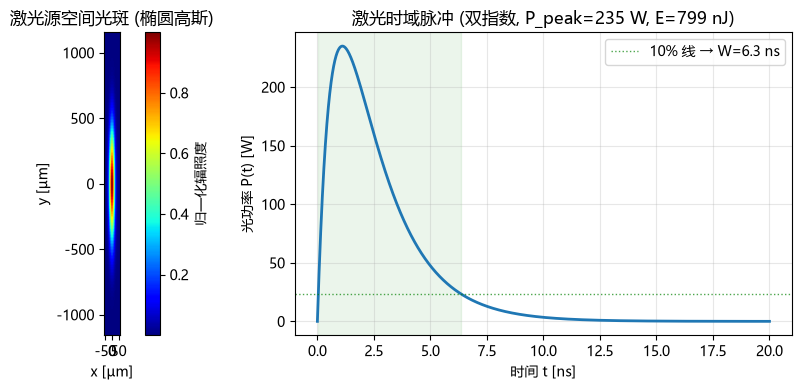

In [14]:
def spot_spatial(x, y, p=PARAMS):
    wx, wy = p["laser"]["x_L"] / 2.0, p["laser"]["y_L"] / 2.0
    return np.exp(-2.0 * (x**2) / wx**2 - 2.0 * (y**2) / wy**2)

def _pulse_norm(p=PARAMS):
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf / tr) / (1.0 / tr - 1.0 / tf)
    s_peak = np.exp(-t_peak / tf) - np.exp(-t_peak / tr)
    area_shape = tf - tr
    A = p["laser"]["E_pulse"] * s_peak / area_shape if p["laser"]["amp_mode"] == "energy" else p["laser"]["P_peak"]
    return A, s_peak, t_peak, area_shape

def pulse_temporal(t, p=PARAMS):
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    shape = np.where(t >= 0, np.exp(-tpos / tf) - np.exp(-tpos / tr), 0.0)
    return A * np.clip(shape, 0.0, None) / s_peak

def pulse_metrics(p=PARAMS):
    """脉冲特征. 主指标 W_10_10 = 上升10%到下降10%的全宽."""
    t = np.linspace(0, 60e-9, 600001)
    P = pulse_temporal(t, p); pk = P.max(); i_pk = np.argmax(P)
    # 上升沿 10% 时刻 / 下降沿 10% 时刻
    t_rise10 = np.interp(0.1 * pk, P[:i_pk + 1], t[:i_pk + 1])
    td, Pd = t[i_pk:], P[i_pk:]
    t_fall10 = np.interp(0.1 * pk, Pd[::-1], td[::-1])
    W_10_10 = t_fall10 - t_rise10
    fwhm = (lambda a: a[-1] - a[0])(t[P >= 0.5 * pk])
    rise = np.interp(0.9 * pk, P[:i_pk + 1], t[:i_pk + 1]) - t_rise10
    fall = t_fall10 - np.interp(0.9 * pk, Pd[::-1], td[::-1])
    energy = np.trapezoid(P, t)
    return {"W_10_10": W_10_10, "FWHM": fwhm, "rise_10_90": rise, "fall_90_10": fall,
            "energy": energy, "peak": pk, "tau_eff": energy / pk,
            "t_rise10": t_rise10, "t_fall10": t_fall10}

_m = pulse_metrics()
print(f"[amp_mode = {PARAMS['laser']['amp_mode']}]")
print(f"峰值功率 P_peak          = {_m['peak']:.1f} W")
print(f"单脉冲能量 E             = {_m['energy']*1e9:.1f} nJ")
print(f"脉宽 W(10%-10% 全宽)     = {_m['W_10_10']*1e9:.2f} ns   ← v2 主指标")
print(f"  (参考 FWHM 半高全宽     = {_m['FWHM']*1e9:.2f} ns)")
print(f"上升(10-90%)={_m['rise_10_90']*1e9:.2f} ns   下降(90-10%)={_m['fall_90_10']*1e9:.2f} ns   τ_eff=E/P={_m['tau_eff']*1e9:.2f} ns")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
gx = np.linspace(-PARAMS["laser"]["x_L"], PARAMS["laser"]["x_L"], 200)
gy = np.linspace(-PARAMS["laser"]["y_L"], PARAMS["laser"]["y_L"], 200)
GX, GY = np.meshgrid(gx, gy)
im = ax[0].pcolormesh(GX * 1e6, GY * 1e6, spot_spatial(GX, GY), shading="auto", cmap="jet")
ax[0].set_title("激光源空间光斑 (椭圆高斯)")
ax[0].set_xlabel("x [µm]"); ax[0].set_ylabel("y [µm]"); ax[0].set_aspect("equal")
plt.colorbar(im, ax=ax[0], label="归一化辐照度")
tt = np.linspace(0, 20e-9, 3000)
ax[1].plot(tt * 1e9, pulse_temporal(tt), lw=2)
ax[1].axhline(_m["peak"]*0.1, color="g", ls=":", lw=1, alpha=0.7, label=f"10% 线 → W={_m['W_10_10']*1e9:.1f} ns")
ax[1].axvspan(_m["t_rise10"]*1e9, _m["t_fall10"]*1e9, color="g", alpha=0.08)
ax[1].set_title(f"激光时域脉冲 (双指数, P_peak={_m['peak']:.0f} W, E={_m['energy']*1e9:.0f} nJ)")
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel("光功率 P(t) [W]")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 模块 2 — TX 发射光学

半发散角 = 几何项 ⊕ 衍射项：`θ_geom=尺寸/(2 f_TX)`，`θ_diff≈λ/(π w0)`，`w0=D_TX/2`。
瑞利距离 `z_R≈w0/θ`。

In [15]:
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "theta_geom_x": tgx, "theta_geom_y": tgy,
            "theta_diff": tdf, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

_tx = tx_derived()
print(f"半发散角  θ_x = {_tx['theta_x']*1e3:.4f} mrad,  θ_y = {_tx['theta_y']*1e3:.4f} mrad")
print(f"  (几何 {_tx['theta_geom_x']*1e3:.4f}/{_tx['theta_geom_y']*1e3:.4f} mrad, 衍射下限 {_tx['theta_diff']*1e3:.4f} mrad)")
print(f"瑞利距离  z_R,x = {_tx['zR_x']:.2f} m,  z_R,y = {_tx['zR_y']:.2f} m")
print(f"出光效率  η_TX = {_tx['eta_TX']:.3f}")

半发散角  θ_x = 0.8346 mrad,  θ_y = 15.9723 mrad
  (几何 0.8333/15.9722 mrad, 衍射下限 0.0454 mrad)
瑞利距离  z_R,x = 7.61 m,  z_R,y = 0.40 m
出光效率  η_TX = 0.800


## 模块 3 — 信道（大气 + 光斑扩展 + 飞行时间）

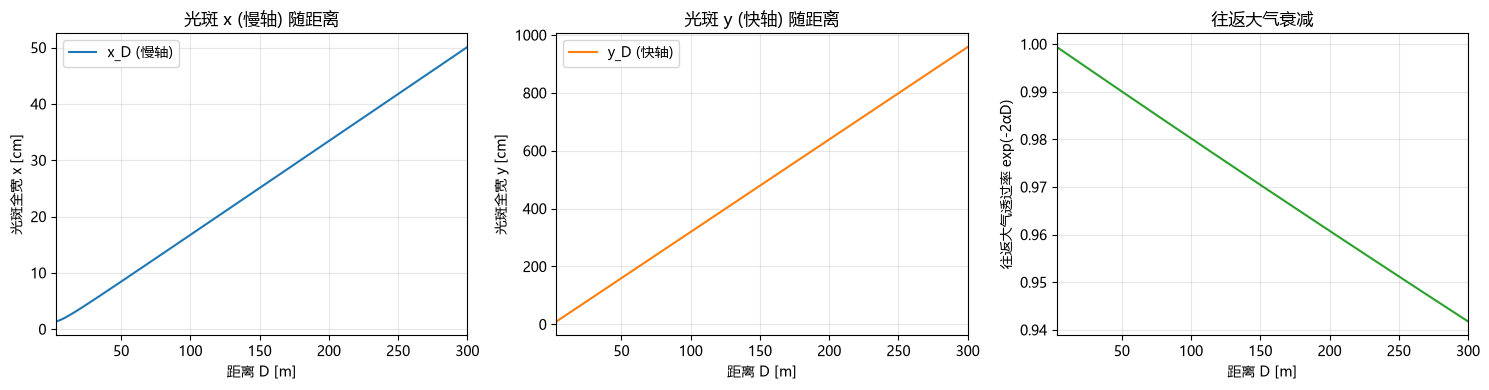

D=   30 m:  光斑   5.17 ×  95.84 cm,  t_ToF=  200.1 ns
D=  120 m:  光斑  20.07 × 383.34 cm,  t_ToF=  800.6 ns
D=  200 m:  光斑  33.41 × 638.89 cm,  t_ToF= 1334.3 ns


In [16]:
def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def beam_area(D, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    return np.pi / 4.0 * x_D * y_D

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

Ds = np.linspace(0.1, D_PLOT_MAX, 600)
xD = np.array([beam_spot_size(d)[0] for d in Ds])
yD = np.array([beam_spot_size(d)[1] for d in Ds])
_mvis3 = Ds >= 3.0    # 只画 D>=3m, 使自动 y 轴聚焦可见区间
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# 光斑 x (慢轴)
ax[0].plot(Ds[_mvis3], xD[_mvis3]*100, color="tab:blue", label="x_D (慢轴)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("光斑全宽 x [cm]")
ax[0].set_title("光斑 x (慢轴) 随距离"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_xlim(3, D_PLOT_MAX)
# 光斑 y (快轴)
ax[1].plot(Ds[_mvis3], yD[_mvis3]*100, color="tab:orange", label="y_D (快轴)")
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("光斑全宽 y [cm]")
ax[1].set_title("光斑 y (快轴) 随距离"); ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_xlim(3, D_PLOT_MAX)
# 往返大气衰减
ax[2].plot(Ds[_mvis3], atm_transmission(Ds[_mvis3])**2, color="tab:green")
ax[2].set_xlabel("距离 D [m]"); ax[2].set_ylabel("往返大气透过率 exp(-2αD)")
ax[2].set_title("往返大气衰减"); ax[2].grid(alpha=0.3); ax[2].set_xlim(3, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    d = e["D"]; xd, yd = beam_spot_size(d)
    print(f"D={d:>5.0f} m:  光斑 {xd*100:6.2f} × {yd*100:6.2f} cm,  t_ToF={time_of_flight(d)*1e9:7.1f} ns")

## 模块 4 — 目标（反射率 + 朗伯漫反射 + 多回波）

朗伯 BRDF（Bidirectional Reflectance Distribution Function，双向反射分布函数）= ρ/π。
倾角展宽：`Δt=2 w tanφ/c`。

In [17]:
def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

def check_frac_sum(p=PARAMS):
    s = sum(e["frac"] for e in p["target"]["echoes"])
    print(f"各回波拦截比例之和 = {s:.2f}  [{'OK' if s<=1+1e-9 else '⚠ >1 不物理'}];  余下 {max(0,1-s):.2f} 穿过")
    return s

check_frac_sum()
for e in PARAMS["target"]["echoes"]:
    sig = echo_range_broadening_sigma(e["D"], e["tilt_deg"])
    print(f"  {e['name']:<16} D={e['D']:>5.0f} m, ρ={e['rho']}, frac={e['frac']}, 倾角={e['tilt_deg']}° → 展宽σ={sig*1e12:.0f} ps")

各回波拦截比例之和 = 1.00  [OK];  余下 0.00 穿过
  近处物体(边缘拦截)       D=   30 m, ρ=0.1, frac=0.3, 倾角=0.0° → 展宽σ=0 ps
  主目标(倾斜墙面)        D=  120 m, ρ=0.1, frac=0.6, 倾角=30.0° → 展宽σ=2614 ps
  远处背景             D=  200 m, ρ=0.1, frac=0.1, 倾角=0.0° → 展宽σ=0 ps


## 模块 5 — RX 接收光学（**修复**像面光斑：几何 ⊕ 衍射）

### LiDAR 方程（扩展目标，1/D²）
$$P_{RX,k}(t)=P\!\left(t-\tfrac{2D_k}{c}\right)\cdot \eta_{TX}\cdot frac_k\cdot \frac{\rho_k}{\pi}\cdot \frac{A_{RX}}{D_k^2}\cdot e^{-2\alpha D_k}\cdot \eta_{RX}\cdot T_{RX}\cdot T_{filter}$$

### 像面光斑尺寸（v2 修复点）
RX 对**扩展目标面**成像。对 D≫f_RX 的目标，成像是"**角度→像面位置**"：像面尺寸 = 目标张角 × f_RX。
目标张角 = 光束在该处的角宽 `x_D(D)/D`（近场用完整高斯束，远场趋于恒定发散角 `x_L/f_TX`）。
几何像斑 `s_geom = (x_D/D)·f_RX`，再与**衍射艾里斑**（Airy disk）平方和合成：
`s = √(s_geom² + s_Airy²)`，`s_Airy = 2.44 λ (f_RX/D_RX)`。

> **旧版错误**：直接用"激光光斑物理尺寸 × 放大率 f_RX/D"当像斑，数值偏大且没有衍射下限。

接收孔径 A_RX = 1.327 cm²,  f/# = 1.92,  艾里斑直径 = 4.25 µm
  D=  30m: 像面光斑  43.26 ×  798.70 µm  → 被照像元 5×80=400
  D= 120m: 像面光斑  42.03 ×  798.63 µm  → 被照像元 5×80=400
  D= 200m: 像面光斑  41.97 ×  798.63 µm  → 被照像元 5×80=400
单像元 iFOV = 0.4000 mrad,  阵列 FOV = 40.0×432.0 mrad
探测效率 η=PDE×填充 = 0.300   累加像元数 n_sum=400 (模式='illuminated')


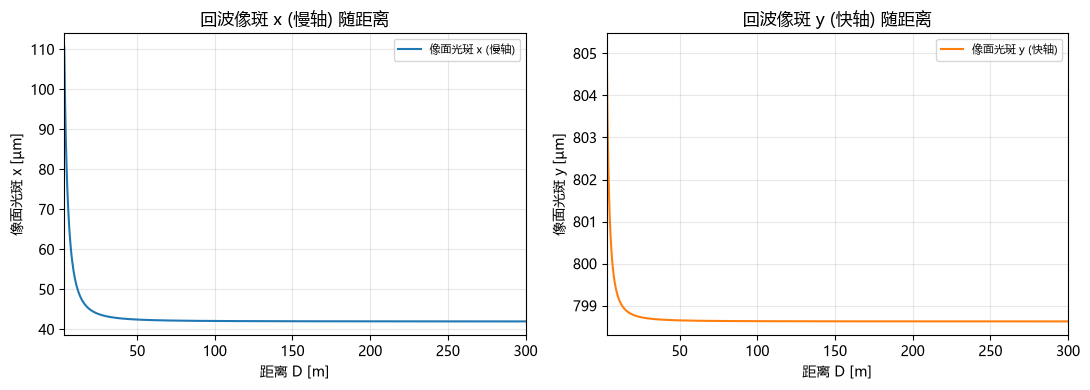

  近处物体(边缘拦截)       link=7.442e-10,  P_RX_peak=174.8934 nW
  主目标(倾斜墙面)        link=9.137e-11,  P_RX_peak=21.4717 nW
  远处背景             link=5.395e-12,  P_RX_peak=1.2679 nW


In [18]:
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def airy_diameter(p=PARAMS):
    """衍射极限像点(艾里斑)直径 [m] = 2.44 λ (f/#)."""
    fnum = p["rx"]["f_RX"] / p["rx"]["D_RX"]
    return 2.44 * p["laser"]["wavelength"] * fnum

def rx_image_spot_size(D, p=PARAMS):
    """RX 像面光斑 [m] = 几何成像(角度×f_RX) ⊕ 衍射艾里斑, 平方和."""
    x_D, y_D = beam_spot_size(D, p)
    s_geom_x = (x_D / D) * p["rx"]["f_RX"]
    s_geom_y = (y_D / D) * p["rx"]["f_RX"]
    s_airy = airy_diameter(p)
    return np.hypot(s_geom_x, s_airy), np.hypot(s_geom_y, s_airy)

def array_geometry(D, p=PARAMS):
    sx, sy = rx_image_spot_size(D, p)
    a = p["spad_array"]
    ncx = int(min(a["Nx"], max(1, np.ceil(sx / a["pitch"]))))
    ncy = int(min(a["Ny"], max(1, np.ceil(sy / a["pitch"]))))
    iFOV = a["pitch"] / p["rx"]["f_RX"]
    return {"spot_x": sx, "spot_y": sy, "ncx": ncx, "ncy": ncy, "n_cov": ncx * ncy,
            "iFOV": iFOV, "fov_x": a["Nx"] * iFOV, "fov_y": a["Ny"] * iFOV}

def eta_detection(p=PARAMS):
    return p["spad"]["PDE"] * p["spad_array"]["fill_factor"]

def n_sum_pixels(p=PARAMS):
    a = p["spad_array"]
    if a["sum_pixels"] == "all":
        return a["Nx"] * a["Ny"]
    primary = max(p["target"]["echoes"], key=lambda e: e["frac"])
    return array_geometry(primary["D"], p)["n_cov"]

def link_factor(echo, p=PARAMS):
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega * atm_transmission(D, p)**2 * eta_rx_total

print(f"接收孔径 A_RX = {rx_area()*1e4:.3f} cm²,  f/# = {PARAMS['rx']['f_RX']/PARAMS['rx']['D_RX']:.2f},  艾里斑直径 = {airy_diameter()*1e6:.2f} µm")
for D in [30, 120, 200]:
    g = array_geometry(D)
    print(f"  D={D:>4}m: 像面光斑 {g['spot_x']*1e6:6.2f} × {g['spot_y']*1e6:7.2f} µm  → 被照像元 {g['ncx']}×{g['ncy']}={g['n_cov']}")
_g120 = array_geometry(120)
print(f"单像元 iFOV = {_g120['iFOV']*1e3:.4f} mrad,  阵列 FOV = {_g120['fov_x']*1e3:.1f}×{_g120['fov_y']*1e3:.1f} mrad")
print(f"探测效率 η=PDE×填充 = {eta_detection():.3f}   累加像元数 n_sum={n_sum_pixels()} (模式='{PARAMS['spad_array']['sum_pixels']}')")

sx_arr = np.array([rx_image_spot_size(d)[0] for d in Ds]) * 1e6
sy_arr = np.array([rx_image_spot_size(d)[1] for d in Ds]) * 1e6
_mvis = Ds >= 3.0    # 只画 D>=3m, 使自动 y 轴聚焦可见区间(近场 D->0 像斑发散会污染范围)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# 左: x (慢轴) 线性
ax[0].plot(Ds[_mvis], sx_arr[_mvis], color="tab:blue", label="像面光斑 x (慢轴)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("像面光斑 x [µm]")
ax[0].set_title("回波像斑 x (慢轴) 随距离"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3); ax[0].set_xlim(3, D_PLOT_MAX)
# 右: y (快轴) 线性
ax[1].plot(Ds[_mvis], sy_arr[_mvis], color="tab:orange", label="像面光斑 y (快轴)")
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("像面光斑 y [µm]")
ax[1].set_title("回波像斑 y (快轴) 随距离"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3); ax[1].set_xlim(3, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    lf = link_factor(e)
    print(f"  {e['name']:<16} link={lf:.3e},  P_RX_peak={PARAMS['laser']['P_peak']*lf*1e9:.4f} nW")

## 模块 6 — SPAD 探测 + 环境光 + 直方图 (TCSPC)

### 环境光噪声（v2 新增, 直接给辐照值）
给定 905nm 处光谱辐照度 `E_λ [W/m²/nm]`，滤光片带宽 `Δλ=12 nm` → 带内辐照 `E=E_λ·Δλ [W/m²]`。
朗伯目标反射 → 辐亮度 `L=ρ·E/π`。单像元经 iFOV 覆盖目标面积 `A_pix=(iFOV·D)²`，RX 立体角 `Ω=A_RX/D²`，
故单像元环境光功率 `P_amb=L·A_pix·Ω`（**与 D 无关**：A_pix∝D²、Ω∝1/D² 抵消）。
计数率 `r_amb=P_amb/E_photon·T_RX·T_filter·PDE`，叠加暗计数 DCR。背景走泊松。

### IRF 与卷积
IRF（仪器响应函数）此处高斯 σ=150ps。bin=1ns≫IRF，故 dt_fine=10ps 精细网格卷积后 rebin 到 1ns。

In [19]:
def ambient_count_rate_per_pixel(p=PARAMS):
    """单像元环境光计数率 [cps] (与距离无关)."""
    if not p["ambient"]["enable"]:
        return 0.0
    E = p["ambient"]["E_lambda"] * (p["rx"]["filter_bw"] * 1e9)   # W/m² (Δλ 以 nm 计)
    L = p["ambient"]["surface_rho"] * E / np.pi                    # W/m²/sr
    iFOV = p["spad_array"]["pitch"] / p["rx"]["f_RX"]
    A_pix_over_D2 = iFOV**2                                        # A_pix/D² = iFOV²
    P_amb = L * A_pix_over_D2 * rx_area(p)
    return P_amb / E_PHOTON * p["rx"]["T_RX"] * p["rx"]["T_filter"] * p["spad"]["PDE"]

def gaussian_kernel(sigma, dt, n_sigma=5):
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def build_expected_histogram(p=PARAMS):
    dt_bin = p["hist"]["bin_width"]; t_max = p["hist"]["t_max"]
    nbins = int(round(t_max / dt_bin))
    tc = (np.arange(nbins) + 0.5) * dt_bin
    dt_fine = p["hist"]["dt_fine"]
    tf = np.arange(0, t_max, dt_fine)
    bin_idx = np.clip((tf / dt_bin).astype(int), 0, nbins - 1)
    N = p["hist"]["N_shots"]; eta = eta_detection(p); sig_irf = p["spad"]["jitter_sigma"]

    per_echo = []; lam_signal = np.zeros(nbins)
    for e in p["target"]["echoes"]:
        t0 = time_of_flight(e["D"])
        r_det = pulse_temporal(tf - t0, p) * link_factor(e, p) / E_PHOTON * eta
        sig = np.hypot(echo_range_broadening_sigma(e["D"], e["tilt_deg"], p), sig_irf)
        r_det = np.convolve(r_det, gaussian_kernel(sig, dt_fine), mode="same") * dt_fine
        lam_e = N * np.bincount(bin_idx, weights=r_det * dt_fine, minlength=nbins)
        lam_signal += lam_e; per_echo.append(lam_e)

    r_amb = ambient_count_rate_per_pixel(p)
    r_bg = (r_amb + p["spad"]["DCR"]) * n_sum_pixels(p)
    lam_bg = np.full(nbins, N * r_bg * dt_bin)
    return {"tc": tc, "dt": dt_bin, "lam_total": lam_signal + lam_bg,
            "lam_signal": lam_signal, "lam_bg": lam_bg, "per_echo": per_echo,
            "r_amb": r_amb, "r_bg": r_bg}

def sample_histogram(expected, seed=0):
    return np.random.default_rng(seed).poisson(expected["lam_total"])

_ramb = ambient_count_rate_per_pixel()
print(f"环境光: E_λ={PARAMS['ambient']['E_lambda']} W/m²/nm × {PARAMS['rx']['filter_bw']*1e9:.0f}nm "
      f"→ 单像元环境光率 r_amb = {_ramb:.3e} cps  (暗计数 DCR={PARAMS['spad']['DCR']:.0e} cps)")
print(f"单像元总背景率 = {_ramb + PARAMS['spad']['DCR']:.3e} cps;  "
      f"1ns bin 内单像元背景期望 = {(_ramb+PARAMS['spad']['DCR'])*1e-9:.2e} /shot")

环境光: E_λ=0.68 W/m²/nm × 12nm → 单像元环境光率 r_amb = 6.107e+06 cps  (暗计数 DCR=0e+00 cps)
单像元总背景率 = 6.107e+06 cps;  1ns bin 内单像元背景期望 = 6.11e-03 /shot


## 模块 7 — 全链路装配 + 可视化（总览 + 每回波特写）

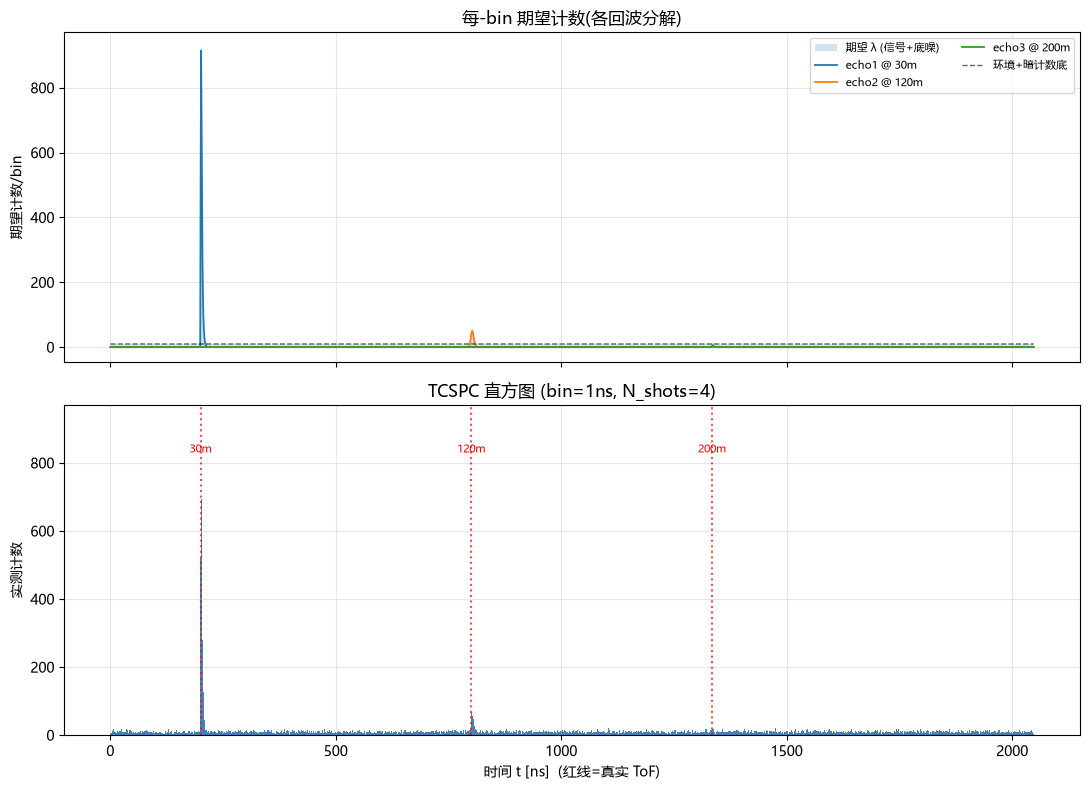

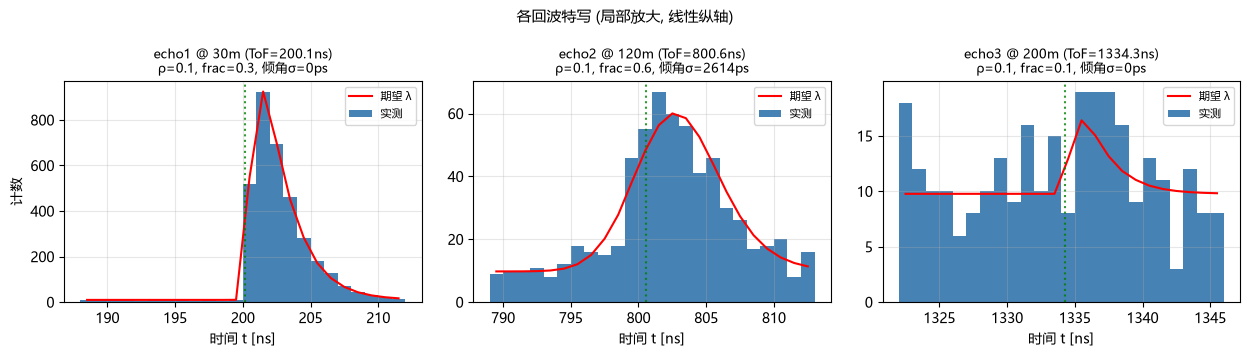

链路预算  (amp_mode=peak, P_peak=235W, E=799nJ, W_10-10=6.31ns)
近处物体(边缘拦截)       D=   30m | 入射   2710.595 ph/pulse | 探测  813.1786 ph/pulse | 累加 3252.7 ph
主目标(倾斜墙面)        D=  120m | 入射    332.780 ph/pulse | 探测   99.8340 ph/pulse | 累加 399.3 ph
远处背景             D=  200m | 入射     19.650 ph/pulse | 探测    5.8950 ph/pulse | 累加 23.6 ph

峰值 bin 计数 ≈ 923  |  信号总光子 ≈ 3675  |  底噪/bin ≈ 9.771 (n_sum=400 像元, r_bg=2.44e+09 cps)


In [20]:
exp = build_expected_histogram(PARAMS)
counts = sample_histogram(exp, seed=PARAMS["hist"]["seed"])
tc_ns = exp["tc"] * 1e9
echoes = PARAMS["target"]["echoes"]

# ---- (A) 总览: 期望分解 + 实测直方图, 线性纵轴 ----
fig, ax = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
ax[0].fill_between(tc_ns, exp["lam_total"], step="mid", alpha=0.20, label="期望 λ (信号+底噪)")
for i, (e, le) in enumerate(zip(echoes, exp["per_echo"])):
    ax[0].plot(tc_ns, le, lw=1.3, label=f"echo{i+1} @ {e['D']:.0f}m")
ax[0].plot(tc_ns, exp["lam_bg"], "k--", lw=1, alpha=0.6, label="环境+暗计数底")
ax[0].set_ylabel("期望计数/bin"); ax[0].set_title("每-bin 期望计数(各回波分解)")
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=0.3)
ax[1].bar(tc_ns, counts, width=(tc_ns[1]-tc_ns[0]), align="center", color="steelblue")
for e in echoes:
    tof_ns = time_of_flight(e["D"]) * 1e9
    ax[1].axvline(tof_ns, color="r", ls=":", alpha=0.7)
    ax[1].text(tof_ns, max(counts.max(), 1)*0.9, f"{e['D']:.0f}m", color="r", fontsize=8, ha="center")
ax[1].set_xlabel("时间 t [ns]  (红线=真实 ToF)"); ax[1].set_ylabel("实测计数")
ax[1].set_title(f"TCSPC 直方图 (bin={PARAMS['hist']['bin_width']*1e9:.0f}ns, N_shots={PARAMS['hist']['N_shots']})")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- (B) 每个 echo 特写: 局部放大, 线性纵轴 ----
ne = len(echoes)
fig, axz = plt.subplots(1, ne, figsize=(4.2*ne, 3.6))
if ne == 1:
    axz = [axz]
for i, (e, le) in enumerate(zip(echoes, exp["per_echo"])):
    tof_ns = time_of_flight(e["D"]) * 1e9
    half = 12
    m = (tc_ns >= tof_ns - half) & (tc_ns <= tof_ns + half)
    axz[i].bar(tc_ns[m], counts[m], width=(tc_ns[1]-tc_ns[0]), align="center", color="steelblue", label="实测")
    axz[i].plot(tc_ns[m], exp["lam_total"][m], "r-", lw=1.5, label="期望 λ")
    axz[i].axvline(tof_ns, color="g", ls=":", alpha=0.8)
    sig = echo_range_broadening_sigma(e["D"], e["tilt_deg"])*1e12
    axz[i].set_title(f"echo{i+1} @ {e['D']:.0f}m (ToF={tof_ns:.1f}ns)\nρ={e['rho']}, frac={e['frac']}, 倾角σ={sig:.0f}ps", fontsize=9)
    axz[i].set_xlabel("时间 t [ns]"); axz[i].grid(alpha=0.3); axz[i].legend(fontsize=8)
axz[0].set_ylabel("计数")
plt.suptitle("各回波特写 (局部放大, 线性纵轴)", fontsize=11)
plt.tight_layout(); plt.show()

# ---- 链路预算 ----
print("=" * 78)
print(f"链路预算  (amp_mode={PARAMS['laser']['amp_mode']}, P_peak={pulse_metrics()['peak']:.0f}W, "
      f"E={pulse_metrics()['energy']*1e9:.0f}nJ, W_10-10={pulse_metrics()['W_10_10']*1e9:.2f}ns)")
print("=" * 78)
eta = eta_detection(); E_pulse_tx = pulse_metrics()["energy"]
for e in echoes:
    lf = link_factor(e); N_inc = lf * E_pulse_tx / E_PHOTON; N_det = N_inc * eta
    print(f"{e['name']:<16} D={e['D']:>5.0f}m | 入射 {N_inc:10.3f} ph/pulse | 探测 {N_det:9.4f} ph/pulse "
          f"| 累加 {N_det*PARAMS['hist']['N_shots']:.1f} ph")
print(f"\n峰值 bin 计数 ≈ {counts.max()}  |  信号总光子 ≈ {int(exp['lam_signal'].sum())}  "
      f"|  底噪/bin ≈ {exp['lam_bg'][0]:.3f} (n_sum={n_sum_pixels()} 像元, r_bg={exp['r_bg']:.2e} cps)")

## 模块 8 — Macro Pixel（宏像元）Binning 与直方图对比（v3 新增）

### 物理
把 `Bx×By` 个物理 SPAD 像元合并成一个**宏像元**，它对应一个接收视场
`视场角 = (B·pitch)/f_RX`，在探测面上就是一个 `Wx×Wy = (Bx·pitch)×(By·pitch)` 的**矩形接收窗口**。
**只有落在这个窗口内的回波像斑光才被接收**，超出窗口的像斑光丢失。

### 接收比例（collection fraction）
回波像斑是**椭圆高斯**（1/e² 全宽 `sx×sy`，来自模块5），高斯标准差 `σ=s/4`
（因 `exp(-2r²/(s/2)²)` 的 1/e² 半宽为 s/2 ⇒ σ=s/4）。矩形窗口 `[-W/2, W/2]` 居中对准像斑中心时，
一维高斯在窗口内的积分为误差函数（erf），二维为其积：
$$f_{coll} = \mathrm{erf}\!\Big(\tfrac{W_x/2}{\sqrt2\,\sigma_x}\Big)\cdot \mathrm{erf}\!\Big(\tfrac{W_y/2}{\sqrt2\,\sigma_y}\Big)$$

### 对直方图的影响（SNR 权衡）
- **信号** ×`f_coll`：某方向窗口没罩住像斑时，加大该方向 binning → 收集更多 → 信号更强。
- **背景**（环境光+暗计数）∝ 宏像元的**物理像元数** `Bx·By`：宏像元越大 → 背景噪声越多。
- 权衡：窗口开到刚好罩住像斑最优；**若某方向已远超像斑，继续加大只增噪声不增信号（SNR 变差）**。

### 本例三种尺寸 6×3 / 9×3 / 12×3（x=短边, y=长边, 全局坐标一致）
坐标约定：**x=短边**（发光区 60µm → 像斑 ~7µm），**y=长边**（发光区 1150µm → 像斑 ~122µm）。
本例 **6/9/12 沿 x(短边)**、**3 沿 y(长边)**：
- x 窗口 60/90/120µm **远超**像斑 7µm ⇒ x 方向三者都≈全收；
- y 窗口固定 30µm **罩不住** 122µm 长条 ⇒ y 方向收集受限且三者相同。
- **结论**：三种收集比例几乎相同(~0.48)，直方图信号峰基本重合；唯一差异是背景像元数 18/27/36
  → 大宏像元 SNR 反而更差。**这是真实光学配置的正确物理结果，不是 bug。**

In [21]:
from scipy.special import erf

def macro_window_size(Bx, By, p=PARAMS):
    """(Bx 沿短边x, By 沿长边y) → 成像面矩形窗口 (Wx, Wy) [m]. 坐标全局一致."""
    pitch = p["spad_array"]["pitch"]
    return Bx * pitch, By * pitch

def collection_fraction(D, Wx, Wy, p=PARAMS):
    """回波像斑(椭圆高斯)落在居中矩形宏像元窗口内的功率比例.
    像斑 1/e^2 全宽 s -> 高斯 σ=s/4. 居中窗口 [-W/2,W/2] 内积分 = erf((W/2)/(√2 σ))."""
    sx, sy = rx_image_spot_size(D, p)               # 1/e^2 全宽 (x=短边, y=长边)
    sig_x, sig_y = sx / 4.0, sy / 4.0               # 高斯 sigma
    fx = erf((Wx / 2.0) / (np.sqrt(2) * sig_x))
    fy = erf((Wy / 2.0) / (np.sqrt(2) * sig_y))
    return fx * fy, fx, fy

def build_histogram_macro(Bx, By, p=PARAMS):
    """给定宏像元尺寸(Bx沿短边x, By沿长边y), 构建期望直方图: 信号×收集比例, 背景∝宏像元物理像元数."""
    Wx, Wy = macro_window_size(Bx, By, p)
    n_macro_pix = Bx * By
    dt_bin = p["hist"]["bin_width"]; t_max = p["hist"]["t_max"]
    nbins = int(round(t_max / dt_bin)); tc = (np.arange(nbins) + 0.5) * dt_bin
    dt_fine = p["hist"]["dt_fine"]; tf = np.arange(0, t_max, dt_fine)
    bin_idx = np.clip((tf / dt_bin).astype(int), 0, nbins - 1)
    N = p["hist"]["N_shots"]; eta = eta_detection(p); sig_irf = p["spad"]["jitter_sigma"]

    per_echo = []; lam_signal = np.zeros(nbins); fcolls = []
    for e in p["target"]["echoes"]:
        t0 = time_of_flight(e["D"])
        fcoll, _, _ = collection_fraction(e["D"], Wx, Wy, p)
        fcolls.append(fcoll)
        r_det = pulse_temporal(tf - t0, p) * link_factor(e, p) / E_PHOTON * eta * fcoll
        sig = np.hypot(echo_range_broadening_sigma(e["D"], e["tilt_deg"], p), sig_irf)
        r_det = np.convolve(r_det, gaussian_kernel(sig, dt_fine), mode="same") * dt_fine
        lam_e = N * np.bincount(bin_idx, weights=r_det * dt_fine, minlength=nbins)
        lam_signal += lam_e; per_echo.append(lam_e)

    r_bg = (ambient_count_rate_per_pixel(p) + p["spad"]["DCR"]) * n_macro_pix   # 背景∝宏像元像元数
    lam_bg = np.full(nbins, N * r_bg * dt_bin)
    return {"tc": tc, "lam_total": lam_signal + lam_bg, "lam_signal": lam_signal,
            "lam_bg": lam_bg, "per_echo": per_echo, "Wx": Wx, "Wy": Wy,
            "Bx": Bx, "By": By, "n_macro_pix": n_macro_pix, "fcolls": fcolls}

# --- 计算三种宏像元 ---
sizes = PARAMS["macro"]["sizes_xy"]      # [(Bx沿短边x, By沿长边y), ...]
results = []
print(f"Macro Pixel Binning (x=短边6/9/12, y=长边固定3, pitch={PARAMS['spad_array']['pitch']*1e6:.0f}µm)")
print("=" * 84)
for (Bx, By) in sizes:
    r = build_histogram_macro(Bx, By, PARAMS)
    results.append((Bx, By, r))
    fc_str = ", ".join(f"{e['D']:.0f}m:{fc:.3f}" for e, fc in zip(PARAMS["target"]["echoes"], r["fcolls"]))
    print(f"{Bx}×{By}: 窗口 {r['Wx']*1e6:.0f}×{r['Wy']*1e6:.0f}µm, {r['n_macro_pix']}像元 | "
          f"收集比例[{fc_str}] | 底噪/bin={r['lam_bg'][0]:.1f} | 峰值信号bin={r['lam_signal'].max():.0f}")

# --- 采样 ---
macro_counts = [(Bx, By, r, sample_histogram(r, seed=PARAMS["hist"]["seed"])) for (Bx, By, r) in results]

Macro Pixel Binning (x=短边6/9/12, y=长边固定3, pitch=10µm)
6×3: 窗口 60×30µm, 18像元 | 收集比例:0.060, 120m:0.060, 200m:0.060] | 底噪/bin=0.4 | 峰值信号bin=54
9×3: 窗口 90×30µm, 27像元 | 收集比例:0.060, 120m:0.060, 200m:0.060] | 底噪/bin=0.7 | 峰值信号bin=55
12×3: 窗口 120×30µm, 36像元 | 收集比例:0.060, 120m:0.060, 200m:0.060] | 底噪/bin=0.9 | 峰值信号bin=55


### 图 A — 三种宏像元的 TCSPC 直方图（并排，线性）

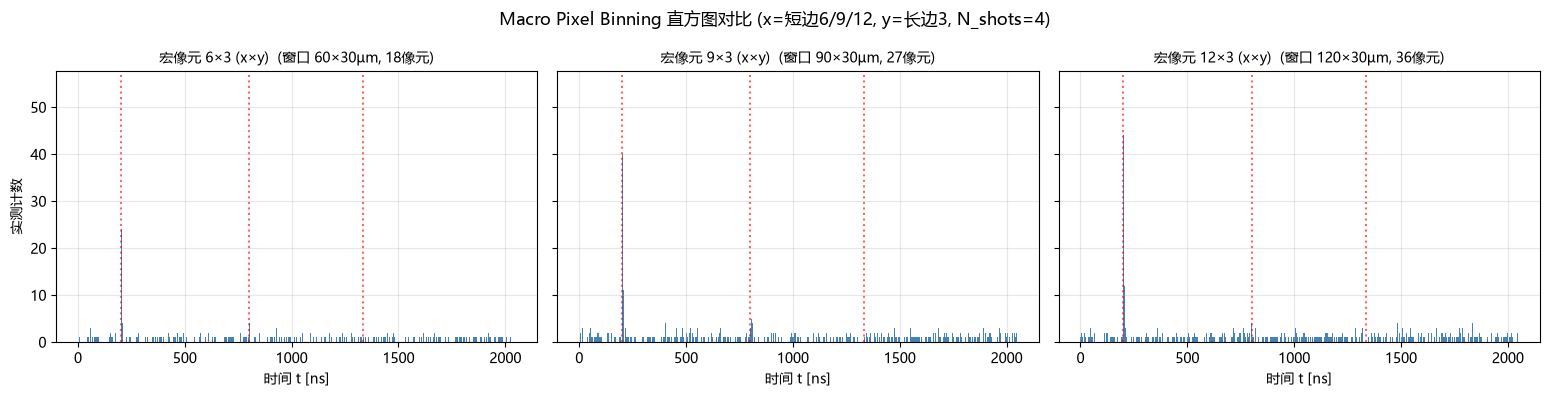

In [22]:
tc_ns = results[0][2]["tc"] * 1e9
echoes = PARAMS["target"]["echoes"]
nS = len(macro_counts)
fig, axs = plt.subplots(1, nS, figsize=(5.2*nS, 4), sharey=True)
if nS == 1: axs = [axs]
for ax, (Bx, By, r, cnts) in zip(axs, macro_counts):
    ax.bar(tc_ns, cnts, width=(tc_ns[1]-tc_ns[0]), align="center", color="steelblue")
    for e in echoes:
        tof_ns = time_of_flight(e["D"]) * 1e9
        ax.axvline(tof_ns, color="r", ls=":", alpha=0.6)
    ax.set_title(f"宏像元 {Bx}×{By} (x×y)  (窗口 {r['Wx']*1e6:.0f}×{r['Wy']*1e6:.0f}µm, {r['n_macro_pix']}像元)", fontsize=10)
    ax.set_xlabel("时间 t [ns]"); ax.grid(alpha=0.3)
axs[0].set_ylabel("实测计数")
plt.suptitle(f"Macro Pixel Binning 直方图对比 (x=短边6/9/12, y=长边3, N_shots={PARAMS['hist']['N_shots']})", fontsize=12)
plt.tight_layout(); plt.show()

### 图 B — 主目标(120m)回波特写：三种宏像元叠放对比

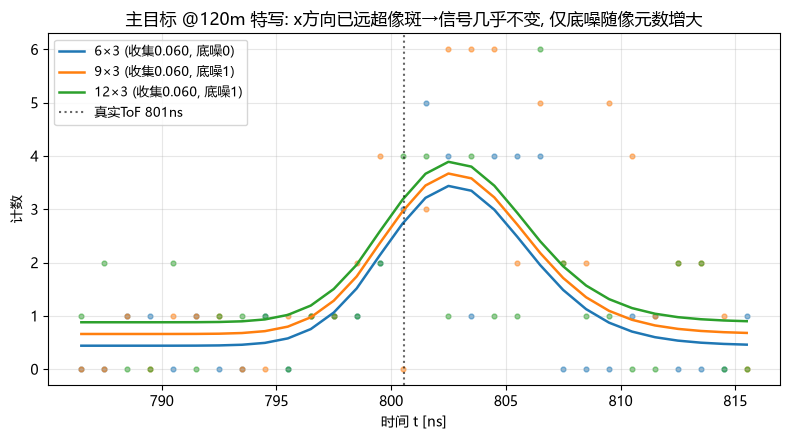

In [23]:
main_e = max(echoes, key=lambda e: e["frac"])       # 主目标
tof_ns = time_of_flight(main_e["D"]) * 1e9
half = 15
m = (tc_ns >= tof_ns - half) & (tc_ns <= tof_ns + half)
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["tab:blue", "tab:orange", "tab:green"]
for (Bx, By, r, cnts), c in zip(macro_counts, colors):
    ax.plot(tc_ns[m], r["lam_total"][m], color=c, lw=1.8,
            label=f"{Bx}×{By} (收集{r['fcolls'][echoes.index(main_e)]:.3f}, 底噪{r['lam_bg'][0]:.0f})")
    ax.scatter(tc_ns[m], cnts[m], color=c, s=12, alpha=0.5)
ax.axvline(tof_ns, color="k", ls=":", alpha=0.6, label=f"真实ToF {tof_ns:.0f}ns")
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel("计数")
ax.set_title(f"主目标 @{main_e['D']:.0f}m 特写: x方向已远超像斑→信号几乎不变, 仅底噪随像元数增大")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 图 C — 信号/背景/信噪比 随宏像元尺寸变化

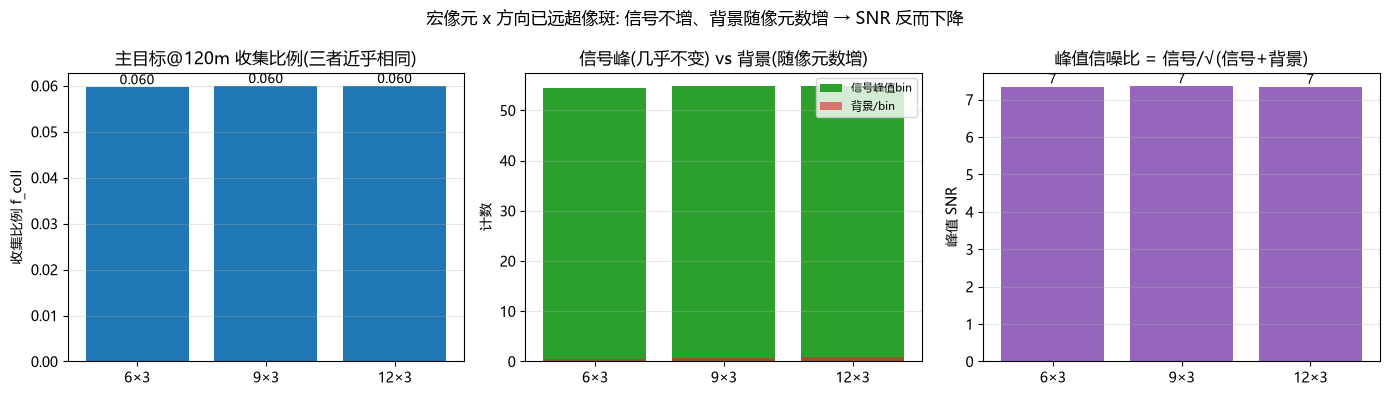

小结(x沿短边6/9/12, y沿长边3): x方向窗口(60/90/120µm)远超像斑(~7µm) → 收集比例几乎不变;
   y方向窗口固定30µm 罩不住122µm长条 → 三者y收集相同. 故信号峰几乎重合, 仅背景随像元数增→SNR下降.
  6×3: 收集(主目标)=0.060, 信号峰=54, 背景/bin=0.4, 像元数=18, 峰值SNR=7
  9×3: 收集(主目标)=0.060, 信号峰=55, 背景/bin=0.7, 像元数=27, 峰值SNR=7
  12×3: 收集(主目标)=0.060, 信号峰=55, 背景/bin=0.9, 像元数=36, 峰值SNR=7


In [24]:
bin_labels = [f"{Bx}×{By}" for (Bx, By, _, _) in macro_counts]
main_idx = echoes.index(main_e)
sig_peak = [r["lam_signal"].max() for (_, _, r, _) in macro_counts]
bg_bin = [r["lam_bg"][0] for (_, _, r, _) in macro_counts]
fcoll_main = [r["fcolls"][main_idx] for (_, _, r, _) in macro_counts]
# 峰值信噪比 SNR = 信号峰 / sqrt(信号峰+背景)  (泊松)
snr = [s / np.sqrt(s + b) for s, b in zip(sig_peak, bg_bin)]

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].bar(bin_labels, fcoll_main, color="tab:blue")
ax[0].set_ylabel("收集比例 f_coll"); ax[0].set_title(f"主目标@{main_e['D']:.0f}m 收集比例(三者近乎相同)"); ax[0].grid(alpha=0.3, axis="y")
for i, v in enumerate(fcoll_main): ax[0].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax[1].bar(bin_labels, sig_peak, color="tab:green", label="信号峰值bin")
ax[1].bar(bin_labels, bg_bin, color="tab:red", alpha=0.6, label="背景/bin")
ax[1].set_ylabel("计数"); ax[1].set_title("信号峰(几乎不变) vs 背景(随像元数增)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, axis="y")
ax[2].bar(bin_labels, snr, color="tab:purple")
ax[2].set_ylabel("峰值 SNR"); ax[2].set_title("峰值信噪比 = 信号/√(信号+背景)"); ax[2].grid(alpha=0.3, axis="y")
for i, v in enumerate(snr): ax[2].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("宏像元 x 方向已远超像斑: 信号不增、背景随像元数增 → SNR 反而下降", fontsize=12)
plt.tight_layout(); plt.show()

print("=" * 84)
print("小结(x沿短边6/9/12, y沿长边3): x方向窗口(60/90/120µm)远超像斑(~7µm) → 收集比例几乎不变;")
print("   y方向窗口固定30µm 罩不住122µm长条 → 三者y收集相同. 故信号峰几乎重合, 仅背景随像元数增→SNR下降.")
for (Bx, By, r, _), s in zip(macro_counts, snr):
    print(f"  {Bx}×{By}: 收集(主目标)={r['fcolls'][main_idx]:.3f}, 信号峰={r['lam_signal'].max():.0f}, "
          f"背景/bin={r['lam_bg'][0]:.1f}, 像元数={r['n_macro_pix']}, 峰值SNR={s:.0f}")